<a href="https://colab.research.google.com/github/Mateo755/Neural-Classification-of-Erythrocyte-Anomalies/blob/main/sandbox_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cells to run if Google Colab is used

In [ ]:
!unzip -q /content/malaria_dataset.zip

In [ ]:
!pip install optuna

In [ ]:
!pip install wandb

In [ ]:
!pip install optuna-integration

In [ ]:
!pip install pytorch-lightning

In [ ]:
!pip install lightning

In [ ]:
import sys
sys.path.append('/content')

# ML libraries versions and CUDA check

In [ ]:
import pytorch_lightning as pl
import torch

print("Lightning version:", pl.__version__)
print("Torch version:", torch.__version__)
print("CUDA is available:", torch.cuda.is_available())

In [ ]:
!nvidia-smi

# Libraries needed

In [ ]:
import os
import random
from PIL import Image

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger, WandbLogger

import wandb

import torch
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, datasets
from torchvision import models

from torchmetrics import Accuracy, F1Score, Precision, Recall, ConfusionMatrix

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
wandb.login()

# Project: Malaria Cell Classification

## 1. Objectives
The goal of this project is to develop a Deep Learning model to classify single-cell images of erythrocytes.
* **Problem:** Binary classification (Healthy vs. Infected).
* **Architecture:** Convolutional Neural Network (CNN).
* **Input:** RGB Microscopic images (varying sizes).
* **Metrics:** Accuracy, Confusion Matrix on a reserved test set.

## 2. Dataset Visualization
Before training, we visualize random samples from the `train` dataset to understand the data characteristics.

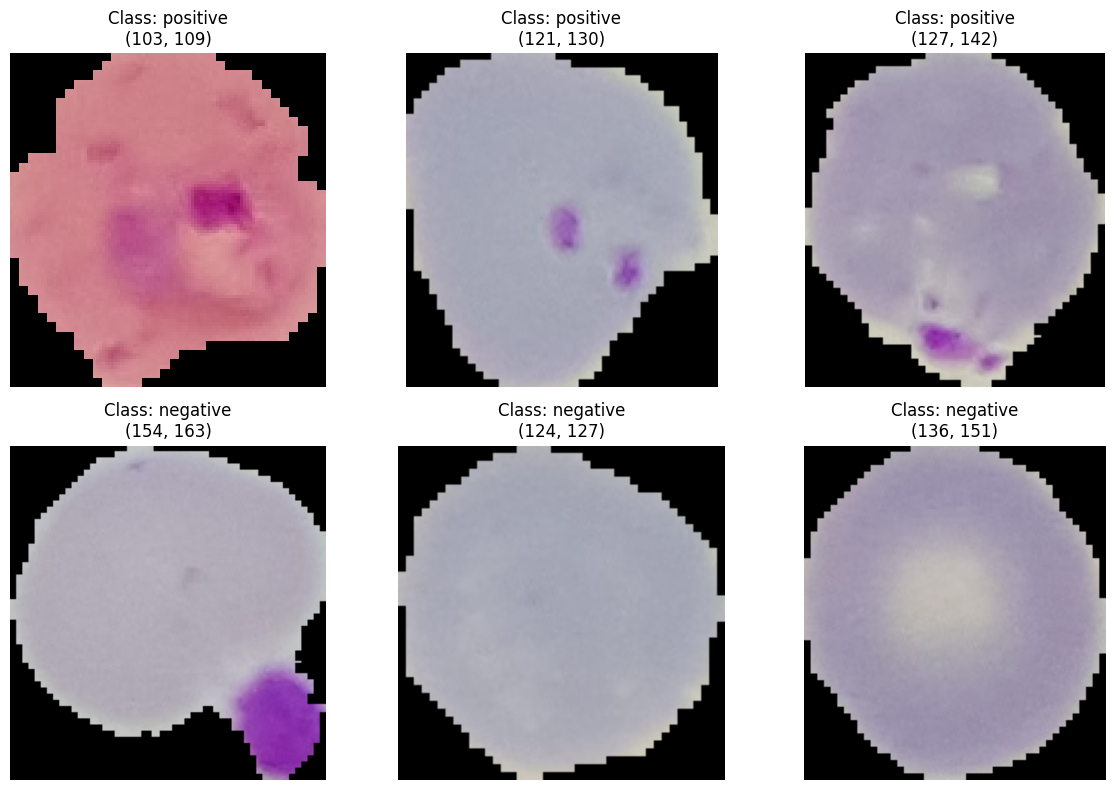

In [87]:
def visualize_samples(base_path='./malaria_dataset/train', num_samples=3):
    """
    Visualizes random samples from 'positive' and 'negative' classes.
    """
    classes = ['positive', 'negative']
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 8))

    for i, cls in enumerate(classes):
        # Path to the specific class folder
        cls_path = os.path.join(base_path, cls)

        # Get all image files
        all_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Select random samples
        selected_files = random.sample(all_files, num_samples)

        for j, file_name in enumerate(selected_files):
            img_path = os.path.join(cls_path, file_name)
            img = Image.open(img_path)

            # Plotting
            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"Class: {cls}\n{img.size}") # Show class and resolution
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
# Make sure the path matches your unzipped dataset location
if os.path.exists('./malaria_dataset/train'):
    visualize_samples('./malaria_dataset/train')
else:
    print("Dataset path not found. Please check the directory structure.")

## 3. Creating data module

In [74]:
# Helper class to add noise (works on Tensors)
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        # Generate noise with the same shape as the image
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'


class MalariaDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str = "./malaria_dataset", batch_size: int = 32, img_size: int = 128):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size

        # Path to the training folder (contains 'positive' and 'negative' subfolders)
        self.train_dir = os.path.join(data_dir, 'train')

        # 1. Define Transforms

        # Training Transforms (With Augmentation)
        # We use this to artificially increase dataset diversity and prevent overfitting.
        self.train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),

            # 1. GEOMETRY (Simulation of cell position)
            # The cell is round/oval and has no "up" or "down", so rotation can be full (+/- 180 degrees)
            transforms.RandomRotation(180),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),

            # Slight shifts and scaling (simulating inaccurate framing)
            # translate=(0.1, 0.1) -> shift by max 10%
            # scale=(0.9, 1.1) -> zoom in/out by 10%
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),

            # 2. COLOR AND QUALITY (Simulation of staining and sharpness)
            # brightness/contrast: lighting variability
            # saturation/hue: variability of staining reagents (e.g., Giemsa violet)
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),

            # Simulation of microscope blur (focus errors)
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))], p=0.2),

            # Simulation of digital sharpness variations (sharpening)
            transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.2),

            # 3. CONVERSION AND NOISE
            transforms.ToTensor(),

            # Adding Gaussian noise (simulation of sensor grain/ISO) - added AFTER converting to Tensor
            transforms.RandomApply([AddGaussianNoise(0., 0.05)], p=0.15),

            # ImageNet Normalization (Important! ResNet50 was trained on this)
            # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] is standard for pretrained models
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Evaluation Transforms (Clean)
        # Used for Validation and Test sets. No random changes, just resizing and normalizing.
        self.eval_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def setup(self, stage=None):
        """
        Splits the data into Train/Val/Test and applies appropriate transformations.
        Approach: We use two separate ImageFolder objects (one augmented, one clean)
        and map indices to them using Subsets.
        """
        if stage == "fit" or stage == "test" or stage is None:
            # STEP 1: Load directory structure to get the total number of images
            # We use a dummy dataset just to read filenames and length
            dummy_ds = datasets.ImageFolder(self.train_dir)
            n_total = len(dummy_ds)

            # STEP 2: Calculate split sizes (80% Train, 10% Val, 10% Test)
            train_len = int(0.8 * n_total)
            val_len = int(0.1 * n_total)
            # The rest goes to test

            # STEP 3: Generate random indices for the split
            # We use a fixed seed generator for reproducibility
            g = torch.Generator().manual_seed(42)
            indices = torch.randperm(n_total, generator=g).tolist()

            train_idx = indices[:train_len]
            val_idx = indices[train_len : train_len + val_len]
            test_idx = indices[train_len + val_len :]

            # STEP 4: Create TWO separate dataset objects with different transforms
            # Dataset A: With Augmentation (for Training)
            train_dataset_obj = datasets.ImageFolder(self.train_dir, transform=self.train_transform)
            # Dataset B: Without Augmentation (for Validation/Testing)
            eval_dataset_obj = datasets.ImageFolder(self.train_dir, transform=self.eval_transform)

            # STEP 5: Create Subsets by mapping indices to the correct dataset object
            self.train_ds = Subset(train_dataset_obj, train_idx)
            self.val_ds = Subset(eval_dataset_obj, val_idx)
            self.test_ds = Subset(eval_dataset_obj, test_idx)

            print(f"--- Data Module Setup Complete ---")
            print(f"Train samples: {len(self.train_ds)} (Augmented)")
            print(f"Val samples:   {len(self.val_ds)} (Clean)")
            print(f"Test samples:  {len(self.test_ds)} (Clean)")
            print(f"Classes:       {dummy_ds.classes}") # Should be ['negative', 'positive']

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=4, persistent_workers=True,  pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=4, persistent_workers=True,  pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, num_workers=4, persistent_workers=True,  pin_memory=True)

## 4. Creating models architecture

In [ ]:
class Resnet(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=False):
        super().__init__()

        # 1. Load Pre-trained ResNet18
        # We use 'DEFAULT' weights which correspond to the best available ImageNet weights
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # 2. Freeze Backbone (Optional strategy)
        # If True, we stop gradient calculation for feature extraction layers.
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Replace the Classification Head
        num_filters = self.backbone.fc.in_features
        # We replace it with a new Linear layer for our binary classification (2 classes)
        self.backbone.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
class CustomResnet(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True,
                 n_layers=4, hidden_dim=128, apply_dropout=False, dropout_rate=0.5):
        super().__init__()

        # 1. Load Pre-trained ResNet50
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # 2. Freeze Backbone (Optional)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Build Custom Classification Head

        # CRITICAL STEP: Get input dimension
        # ResNet50 outputs 2048 features from its convolutional layers.
        # We MUST capture this value dynamically to connect our new layers correctly.
        # If we didn't do this, we wouldn't know the input size for the first Linear layer.
        in_features = self.backbone.fc.in_features  # Value is 2048 for ResNet50

        layers = []
        current_dim = in_features  # Start with 2048

        # Loop to create the hidden layers (Depth = 4)
        for x in range(n_layers):
            # Connect current dimension to the hidden dimension (e.g., 2048 -> 128, then 128 -> 128)
            hidden_dim = int(hidden_dim)
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())

            # Logic for Dropout (disabled based on your Optuna results)
            if apply_dropout:
                layers.append(nn.Dropout(dropout_rate))

            # Update current_dim so the next layer knows what to expect
            current_dim = hidden_dim

        # 4. Final Output Layer
        # Maps the last hidden layer (128) to the number of classes (2)
        layers.append(nn.Linear(current_dim, num_classes))

        # 5. Replace the original ResNet head with our new sequence
        self.backbone.fc = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the entire network (Backbone + New Head)
        return self.backbone(x)

In [75]:
class CustomEfficientnet(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True,
                 n_layers=4, hidden_dim=128, apply_dropout=False, dropout_rate=0.5):
        super().__init__()


        self.backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[-1].in_features

        layers = []
        current_dim = in_features


        for _ in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if apply_dropout:
                layers.append(nn.Dropout(dropout_rate))

            current_dim = hidden_dim


        layers.append(nn.Linear(current_dim, num_classes))


        self.backbone.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
class CustomViT(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True,
                 n_layers=4, hidden_dim=128, apply_dropout=False, dropout_rate=0.5):
        super().__init__()


        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.heads[-1].in_features

        layers = []
        current_dim = in_features


        for _ in range(n_layers):
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if apply_dropout:
                layers.append(nn.Dropout(dropout_rate))

            current_dim = hidden_dim


        layers.append(nn.Linear(current_dim, num_classes))


        self.backbone.heads = nn.Sequential(*layers)

    def forward(self, x):
        return self.backbone(x)

## 5. Creating main lightning module

In [77]:
class MalariaClassifier(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3, weight_decay=0.0, num_classes=2):
        super().__init__()
        # ignore=['model'] jest ważne, żeby checkpoint nie zapisywał całego obiektu modelu w hyperparametrach
        self.save_hyperparameters(ignore=['model'])

        self.model = model

        #  Define Metrics
        # 'task="multiclass"' with 2 classes is standard for CrossEntropyLoss
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)

        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_prec = Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.test_rec = Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.test_f1 = F1Score(task="multiclass", num_classes=num_classes, average='macro')
        self.test_cm = ConfusionMatrix(task="multiclass", num_classes=num_classes)

    def forward(self, X):
        # Forward pass through the network
        return self.model(X)

    def _common_step(self, batch, batch_idx):
        X, y = batch
        logits = self(X)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._common_step(batch, batch_idx)

        # Logging metrics
        self.train_acc(preds, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._common_step(batch, batch_idx)

        # Logging validation metrics
        self.val_acc(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
            loss, preds, y = self._common_step(batch, batch_idx)

            # Update all test metrics
            self.test_acc(preds, y)
            self.test_prec(preds, y)
            self.test_rec(preds, y)
            self.test_f1(preds, y)
            self.test_cm(preds, y) # Accumulate confusion matrix

            # Log scalar metrics
            self.log_dict({
                'test_loss': loss,
                'test_acc': self.test_acc,
                'test_precision': self.test_prec,
                'test_recall': self.test_rec,
                'test_f1': self.test_f1
            })
            return loss

    def on_test_epoch_end(self):
        """
        Executed once at the end of the test epoch.
        """
        # 1. Compute the confusion matrix
        cm = self.test_cm.compute().cpu().numpy()

        # 2. Define class names
        classes = ['negative', 'positive']

        # 3. Create figure using Seaborn
        plt.figure(figsize=(10, 8))

        df_cm = pd.DataFrame(cm, index=classes, columns=classes)

        sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')

        plt.title('Test Confusion Matrix')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')

        # 4. Save the plot locally
        save_path = "confusion_matrix.png"
        plt.savefig(save_path)
        plt.close()
        print(f"--> Confusion Matrix saved locally to: {save_path}")

        # 5. Upload to W&B
        if self.logger and hasattr(self.logger, "experiment"):
            try:
                import wandb
                self.logger.experiment.log({
                    "confusion_matrix_img": wandb.Image(save_path, caption="Confusion Matrix")
                })
                print("--> Confusion Matrix uploaded to W&B.")
            except Exception as e:
                print(f"Warning: Could not upload to W&B. Error: {e}")

        # 6. Reset metric
        self.test_cm.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate, weight_decay=self.hparams.weight_decay)

        # Optional: Learning Rate Scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.2, patience=2
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

## 6. Starting training process

In [79]:
# --- CONFIGURATION ---
HYPERPARAMETERS = {
    # Architecture Params (from model_builder)
    "num_classes": 2,
    "n_layers": 4,
    "hidden_dim": 128,
    "apply_dropout": False,
    "dropout_rate": 0.2,
    "freeze_backbone": False,
    "base_model": "efficientnet_v2_S",
    "base_model_weights": "IMAGENET1K_V2",

    # Training Params
    "batch_size": 32,
    "img_size": 224,
    "epochs": 50,
    "learning_rate": 9.0e-05,
    "optimizer": "Adam",
    "weight_decay": 2.3e-05,
    "early_stopping_patience": 5,
    "seed": 42
}

### 6.1 Logging conf

In [80]:
from IPython.core.magics import config
# --- LOGGING CONFIGURATION ---
USE_WANDB = True  # Change to False, if you want to disable W&B
logs_dir = "malaria_efficientnet_v2_S"
exp_name = "efficientnet_v2_S"

csv_logger = CSVLogger("logs", name=logs_dir)
loggers_list = [csv_logger]

if USE_WANDB:
    wandb.login()

    wandb_logger = WandbLogger(
        project="Malaria-Classification",
        name=exp_name,
        config=HYPERPARAMETERS,
        log_model="all"  # Change to "all" to log checkpoints to the cloud
    )
    loggers_list.append(wandb_logger)
    print("--> WandbLogger added to configuration.")
else:
    print("--> WandbLogger skipped. Using only CSVLogger.")

--> WandbLogger added to configuration.


### 6.2 Train loop

In [ ]:
# 1. Creating model architecture
backbone = CustomEfficientnet(HYPERPARAMETERS['num_classes'],
                        freeze_backbone=HYPERPARAMETERS['freeze_backbone'],
                        n_layers=HYPERPARAMETERS['n_layers'],
                        hidden_dim=HYPERPARAMETERS['hidden_dim'],
                        apply_dropout=HYPERPARAMETERS['apply_dropout'],
                        dropout_rate=HYPERPARAMETERS['dropout_rate']
                        )
# backbone = Resnet(num_classes=2, freeze_backbone=True)

# 2. Creating training system
model = MalariaClassifier(model=backbone,
                          learning_rate=HYPERPARAMETERS['learning_rate'],
                          weight_decay = HYPERPARAMETERS['weight_decay'])

# 3. Init DataModule
dm = MalariaDataModule(data_dir='./malaria_dataset',
                       batch_size=HYPERPARAMETERS['batch_size'],
                       img_size=HYPERPARAMETERS['img_size'])


# 4. Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints',
    filename='malaria-'+f'{HYPERPARAMETERS['base_model']}'+'-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)

# - EarlyStopping: Stops training if validation loss doesn't improve for 'patience' epochs
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=HYPERPARAMETERS['early_stopping_patience'],
    mode='min'
)

# 5. Trainer
trainer = pl.Trainer(
    max_epochs=HYPERPARAMETERS['epochs'],
    accelerator="auto",    # Automatically detects GPU
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=loggers_list,
    # Optional: log every N steps
    log_every_n_steps=10
)

# 6. Start Training
trainer.fit(model, datamodule=dm)

# best_model_path = checkpoint_callback.best_model_path
# if best_model_path and USE_WANDB:
#     print(f"Uploading final model: {best_model_path}")
#     wandb.save(best_model_path)

## 7. Plot Train process charts

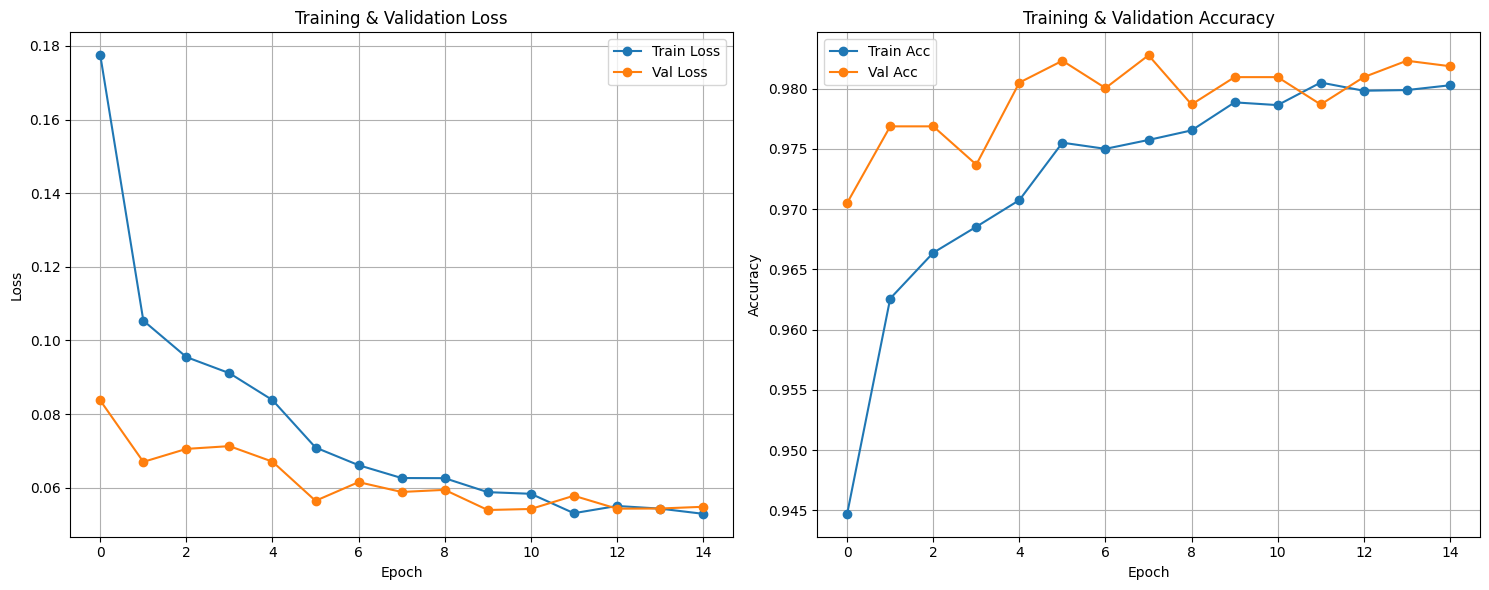

In [82]:
def plot_training_metrics(trainer):
    # 1. Download the path from trainer
    metrics_path = f"{trainer.logger.log_dir}/metrics.csv"

    # 2. Data loading
    metrics = pd.read_csv(metrics_path)

    # 3. Aggregating by epoch
    metrics_epoch = metrics.groupby("epoch").mean(numeric_only=True)

    # 4. Rysowanie
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot A: Loss
    if 'train_loss' in metrics_epoch.columns and 'val_loss' in metrics_epoch.columns:
        axes[0].plot(metrics_epoch.index, metrics_epoch['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(metrics_epoch.index, metrics_epoch['val_loss'], label='Val Loss', marker='o')
        axes[0].set_title('Training & Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)

    # Plot B: Accuracy
    if 'train_acc' in metrics_epoch.columns and 'val_acc' in metrics_epoch.columns:
        axes[1].plot(metrics_epoch.index, metrics_epoch['train_acc'], label='Train Acc', marker='o')
        axes[1].plot(metrics_epoch.index, metrics_epoch['val_acc'], label='Val Acc', marker='o')
        axes[1].set_title('Training & Validation Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Plot training metrics
plot_training_metrics(trainer)

## 8. Testing process

In [83]:
results = trainer.test(model, datamodule=dm, ckpt_path='best')

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/malaria-efficientnet_v2_S-epoch=09-val_loss=0.05.ckpt


--- Data Module Setup Complete ---
Train samples: 17636 (Augmented)
Val samples:   2204 (Clean)
Test samples:  2206 (Clean)
Classes:       ['negative', 'positive']


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/malaria-efficientnet_v2_S-epoch=09-val_loss=0.05.ckpt


Output()

--> Confusion Matrix saved locally to: confusion_matrix.png

Warning: Could not upload to W&B. Error: 'ExperimentWriter' object has no attribute 'log'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.978694498538971     │
│          test_f1          │    0.9786902666091919     │
│         test_loss         │    0.06449475884437561    │
│      test_precision       │     0.978725790977478     │
│        test_recall        │    0.9786648154258728     │
└───────────────────────────┴───────────────────────────┘

## 9. If w&b is turn on, finish the experiment

In [ ]:
if USE_WANDB:
    wandb.finish()

# 10. Evaluate

Analyzing classifier head structure from ckpt file

In [ ]:
import torch

# Path to your checkpoint file
CKPT_PATH = "checkpoints/malaria-efficientnet_v2-epoch=13-val_loss=0.06.ckpt"

print(f"--> Analyzing file: {CKPT_PATH}")
checkpoint = torch.load(CKPT_PATH, map_location="cpu")

# Retrieve the weights dictionary
state_dict = checkpoint["state_dict"]

print("\n--- FOUND CLASSIFIER LAYERS ---")
# Filter only classifier keys to avoid cluttering the screen with the entire EfficientNet
classifier_keys = [k for k in state_dict.keys() if "classifier" in k]

for key in classifier_keys:
    # Print key name and weight shape (this tells us how many neurons there are)
    print(f"{key} \t Shape: {state_dict[key].shape}")

print("\n--------------------------------------")

In [85]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm


class BlindTestDataset(Dataset):
    """
    Custom Dataset to handle a flat folder of images (no class subfolders).
    Returns the image tensor and the filename.
    """

    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        # Sort files to ensure deterministic order of predictions
        # Filter only for image extensions
        self.image_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load image and convert to RGB (standard for ImageNet models)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Return image AND filename (filename is needed for the CSV)
        return image, img_name


def create_submission_from_checkpoint(checkpoint_path, test_dir, config, output_file="submission.csv"):
    """
    Loads a model from a .ckpt file, runs inference on a blind test set,
    and generates the submission CSV.
    """
    print(f"--> Loading checkpoint: {checkpoint_path}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--> Inference Device: {device}")

    # ---------------------------------------------------------
    # 1. RECONSTRUCT ARCHITECTURE
    # We must instantiate the model structure EXACTLY as it was trained.
    # The weights from the checkpoint will simply not fit if shapes differ.
    # ---------------------------------------------------------
    backbone = CustomEfficientnet(
        num_classes=2,
        freeze_backbone=False,  # False is safer for loading (ensures all params exist)
        n_layers=config['n_layers'],
        hidden_dim=config['hidden_dim'],
        apply_dropout=config['apply_dropout']
    )

    # ---------------------------------------------------------
    # 2. LOAD WEIGHTS INTO SYSTEM
    # We use .load_from_checkpoint() and inject our backbone object.
    # We pass dummy values for lr/optimizer because they are required by __init__
    # but strictly irrelevant for inference.
    # ---------------------------------------------------------
    model_system = MalariaClassifier.load_from_checkpoint(
        checkpoint_path,
        model=backbone,
    )

    #model_system = model

    model_system.eval()  # Switch to evaluation mode (disable Dropout, BatchNorm stats)
    model_system.freeze()  # Disable gradient calculation
    model_system.to(device)

    # ---------------------------------------------------------
    # 3. PREPARE DATA
    # Use ImageNet normalization and Resize from config
    # ---------------------------------------------------------
    test_transform = transforms.Compose([
        transforms.Resize((config['img_size'], config['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_dataset = BlindTestDataset(img_dir=test_dir, transform=test_transform)
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=2
    )

    # ---------------------------------------------------------
    # 4. PREDICTION LOOP
    # ---------------------------------------------------------
    filenames = []
    predictions = []

    print(f"--> Starting prediction on {len(test_dataset)} images...")

    for imgs, fnames in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(device)

        with torch.no_grad():
            logits = model_system(imgs)
            # Apply Softmax to get probabilities (optional, good for debugging)
            probs = torch.softmax(logits, dim=1)
            # Get the class index (0 or 1) with higher probability
            preds = torch.argmax(probs, dim=1)

        predictions.extend(preds.cpu().numpy())
        filenames.extend(fnames)

    # ---------------------------------------------------------
    # 5. SAVE CSV
    # ---------------------------------------------------------
    df = pd.DataFrame({
        "filename": filenames,
        "prediction": predictions
    })

    # Optional: Verify mapping
    # Usually: 0 -> Negative, 1 -> Positive (based on alphabetical folder order during training)
    print("--> Sample predictions:")
    print(df.head())

    df.to_csv(output_file, index=False)
    print(f"Submission saved to: {output_file}")


# --- EXECUTION BLOCK ---
if __name__ == "__main__":

    # A. CONFIGURATION (Must match the training config!)
    # Ideally, copy this from your training script or WandB config
    INFERENCE_CONFIG = {
        "n_layers": 4,
        "hidden_dim": 128,
        "apply_dropout": False,
        "img_size": 224,
        "batch_size": 32
    }

    # B. PATHS
    # Replace with your actual best checkpoint path
    CKPT_PATH = "checkpoints/malaria-efficientnet_v2_S-epoch=09-val_loss=0.05.ckpt"
    # Path to the folder containing flat images
    TEST_IMAGES_DIR = "./malaria_dataset/test"

    # Check if files exist
    if os.path.exists(CKPT_PATH) and os.path.exists(TEST_IMAGES_DIR):
        create_submission_from_checkpoint(
            checkpoint_path=CKPT_PATH,
            test_dir=TEST_IMAGES_DIR,
            config=INFERENCE_CONFIG
        )
    else:
        print("Error: Checkpoint or Test Directory not found.")

--> Loading checkpoint: checkpoints/malaria-efficientnet_v2_S-epoch=09-val_loss=0.05.ckpt
--> Inference Device: cuda
--> Starting prediction on 5512 images...


Inference: 100%|██████████| 173/173 [00:07<00:00, 22.22it/s]

--> Sample predictions:
                               filename  prediction
0  00061bc487fad4318a37c8694679b942.png           1
1  0006300dc385ef25f0864cf182052128.png           0
2  0006c9205c7a5f1222f935df5db9ece7.png           0
3  003d116e94945be882584e0bf003e383.png           0
4  003fe511f2754144bec6404a30b606db.png           0
Submission saved to: submission.csv


# 11. Submission result check

In [86]:
!curl -X POST --data-binary @submission.csv https://zpo.putvision.pl

{"accuracy": 0.9822206095791002}